<a href="https://colab.research.google.com/github/asolergayoso/DS_5500_Ransomware_Detection/blob/develop/TranAD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from TSB_AD.models.TranAD import TranAD
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score, auc, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_pickle('/content/all_sys_config_10s_1s.pkl')

In [ ]:
!pip install TSB-AD

In [4]:
df.head()

,start,end,avg_ata_read,avg_ata_write,lba_read_var,lba_write_var,avg_storage_entropy,avg_entropy_mem_write,avg_entropy_mem_read_write,num_4KB_pages_mem_read,...,mem_exec_avg_gpa_jump,mem_exec_max_gpa_jump,mem_exec_access_locality,mem_exec_frwrd_bckwrd_ratio,mem_exec_gpa_range,is_ransomware,operation,execution_id,execution_log_cnt,sys_config
0,0 days 00:00:00,0 days 00:00:10,7651840.0,3704422.4,5.503250e+14,7.344057e+14,0.833415,0.010552,0.839345,11.0,...,3.844968e+09,1.927498e+10,1.0,0.988889,1.954823e+10,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
1,0 days 00:00:01,0 days 00:00:11,8012288.0,4490444.8,5.571908e+14,1.368933e+15,0.838371,0.009608,0.849257,11.0,...,4.403774e+09,1.281490e+10,1.0,0.947368,1.954823e+10,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
2,0 days 00:00:02,0 days 00:00:12,9801420.8,4525670.4,5.137275e+14,1.382114e+15,0.838417,0.009030,0.932870,12.0,...,3.756318e+09,7.914538e+09,1.0,1.000000,7.914702e+09,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
3,0 days 00:00:03,0 days 00:00:13,10182348.8,5762252.8,2.625399e+14,1.749897e+15,0.856967,0.024508,0.870674,10.0,...,3.756318e+09,7.914538e+09,1.0,1.000000,7.914702e+09,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g
4,0 days 00:00:04,0 days 00:00:14,11675648.0,6299289.6,2.446092e+14,1.804892e+15,0.869772,0.028997,0.870674,10.0,...,3.756318e+09,7.914538e+09,1.0,1.000000,7.914702e+09,False,AESCrypt,AESCrypt-20240228_12-09-05,9,extra_i3-gen12_ddr5-4800-16g


In [11]:
ransomware_operations = []
non_ransomware_operations = []

operation_groups = df.groupby('operation')['is_ransomware'].unique()

for operation, is_ransomware_values in operation_groups.items():
    if True in is_ransomware_values:
        ransomware_operations.append(operation)
    else:
        non_ransomware_operations.append(operation)

print(f"Ransomware Operations: {ransomware_operations}")
print(f"Non-Ransomware Operations: {non_ransomware_operations}")

Ransomware Operations: ['Conti', 'Darkside', 'LockBit', 'REvil', 'Ryuk', 'WannaCry']
Non-Ransomware Operations: ['AESCrypt', 'AESCrypt_Conti', 'AESCrypt_REvil', 'Firefox', 'Firefox_Conti', 'Firefox_Office_REvil', 'Firefox_REvil', 'Idle', 'Office', 'Office_REvil', 'SDelete', 'SDelete_Conti', 'SDelete_REvil', 'Zip', 'Zip_Conti', 'Zip_REvil']


In [12]:
selected_train_non_ransomware_operations = [
    'AESCrypt', 'Zip', 'Idle', 'Office', 'SDelete',
]

selected_test_ransomware_operation = 'Conti'

selected_test_non_ransomware_operation = 'Firefox'

print(f"Selected Non-Ransomware Operations for Training: {selected_train_non_ransomware_operations}")
print(f"Selected Ransomware Operation for Test: {selected_test_ransomware_operation}")
print(f"Selected Non-Ransomware Operation for Test: {selected_test_non_ransomware_operation}")


Selected Non-Ransomware Operations for Training: ['AESCrypt', 'Zip', 'Idle', 'Office', 'SDelete']
Selected Ransomware Operation for Test: Conti
Selected Non-Ransomware Operation for Test: Firefox


In [13]:
df_train_filtered = df[df['operation'].isin(selected_train_non_ransomware_operations)].copy()

X_train_raw = df_train_filtered[input_features].values
y_train = df_train_filtered['is_ransomware'].astype(int).values

test_operations = [selected_test_ransomware_operation, selected_test_non_ransomware_operation]
df_test_filtered = df[df['operation'].isin(test_operations)].copy()

X_test_raw = df_test_filtered[input_features].values
y_test = df_test_filtered['is_ransomware'].astype(int).values

print(f"Shape of X_train_raw: {X_train_raw.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test_raw: {X_test_raw.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train_raw: (137429, 104)
Shape of y_train: (137429,)
Shape of X_test_raw: (56378, 104)
Shape of y_test: (56378,)


In [15]:
stds_new = np.std(X_train_raw, axis=0)
zero_std_cols_mask_new = (stds_new == 0)

X_train_filtered_new = X_train_raw[:, ~zero_std_cols_mask_new]
X_test_filtered_new = X_test_raw[:, ~zero_std_cols_mask_new]

print(f"Original number of features (new data): {X_train_raw.shape[1]}")
print(f"Number of features after removing zero-std columns (new data): {X_train_filtered_new.shape[1]}")
print(f"Shape of filtered training features (new data): {X_train_filtered_new.shape}")
print(f"Shape of filtered test features (new data): {X_test_filtered_new.shape}")

Original number of features (new data): 104
Number of features after removing zero-std columns (new data): 100
Shape of filtered training features (new data): (137429, 100)
Shape of filtered test features (new data): (56378, 100)


In [16]:
X_train_filtered_new = np.nan_to_num(X_train_filtered_new, nan=0.0, posinf=0.0, neginf=0.0)
X_test_filtered_new = np.nan_to_num(X_test_filtered_new, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Shape of X_train_filtered_new after NaN/Inf handling: {X_train_filtered_new.shape}")
print(f"Shape of X_test_filtered_new after NaN/Inf handling: {X_test_filtered_new.shape}")

print(f"NaNs in X_train_filtered_new: {np.sum(np.isnan(X_train_filtered_new))}")
print(f"Infs in X_train_filtered_new: {np.sum(np.isinf(X_train_filtered_new))}")
print(f"NaNs in X_test_filtered_new: {np.sum(np.isnan(X_test_filtered_new))}")
print(f"Infs in X_test_filtered_new: {np.sum(np.isinf(X_test_filtered_new))}")

Shape of X_train_filtered_new after NaN/Inf handling: (137429, 100)
Shape of X_test_filtered_new after NaN/Inf handling: (56378, 100)
NaNs in X_train_filtered_new: 0
Infs in X_train_filtered_new: 0
NaNs in X_test_filtered_new: 0
Infs in X_test_filtered_new: 0


In [17]:
scaler_new = MinMaxScaler()
X_train_scaled_new = scaler_new.fit_transform(X_train_filtered_new)
X_test_scaled_new = scaler_new.transform(X_test_filtered_new)

print(f"Shape of cleaned and scaled training features (new data): {X_train_scaled_new.shape}")
print(f"Shape of cleaned and scaled test features (new data): {X_test_scaled_new.shape}")

print(f"NaNs in X_train_scaled_new: {np.sum(np.isnan(X_train_scaled_new))}")
print(f"Infs in X_train_scaled_new: {np.sum(np.isinf(X_train_scaled_new))}")
print(f"NaNs in X_test_scaled_new: {np.sum(np.isnan(X_test_scaled_new))}")
print(f"Infs in X_test_scaled_new: {np.sum(np.isinf(X_test_scaled_new))}")

Shape of cleaned and scaled training features (new data): (137429, 100)
Shape of cleaned and scaled test features (new data): (56378, 100)
NaNs in X_train_scaled_new: 0
Infs in X_train_scaled_new: 0
NaNs in X_test_scaled_new: 0
Infs in X_test_scaled_new: 0


In [ ]:

epochs = 10
batch_size = 128
lr = 1e-4
dropout = 0.2
window_size = 15
feature_dim = X_train_scaled_new.shape[1]

device = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Training TSB-AD TranAD on new split:\n  Train shape: {X_train_scaled_new.shape}\n  Test shape: {X_test_scaled_new.shape}\n  Features: {feature_dim}\n  Device: {device}")

model_tsbad_new = TranAD(
    epochs=epochs,
    batch_size=batch_size,
    lr=lr,
    feats=feature_dim,
    win_size=window_size
)


model_tsbad_new.fit(X_train_scaled_new)

Training TSB-AD TranAD on new split:
  Train shape: (137429, 100)
  Test shape: (56378, 100)
  Features: 100
  Device: cuda
----- Using GPU 0 -----


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer was not TransformerEncoderLayer
  warnings.warn(
Validation Epoch [8/10]: 100%|██████████| 215/215 [00:01<00:00, 129.56it/s, avg_loss_val=0.000723, loss=0.00108]


EarlyStopping counter: 1 out of 3


Validation Epoch [9/10]: 100%|██████████| 215/215 [00:01<00:00, 130.55it/s, avg_loss_val=0.000686, loss=0.00101]


EarlyStopping counter: 2 out of 3


Validation Epoch [10/10]: 100%|██████████| 215/215 [00:01<00:00, 129.94it/s, avg_loss_val=0.000619, loss=0.000944]


In [ ]:
print("Generating anomaly scores for the specific test operations...")
anomaly_scores_new = model_tsbad_new.decision_function(X_test_scaled_new)

roc_auc_new = roc_auc_score(y_test, anomaly_scores_new)
print(f"ROC AUC Score (New Split): {roc_auc_new:.4f}")

precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores_new)
f1_scores = 2 * (precision * recall) / (precision + recall)
f1_scores[np.isnan(f1_scores)] = 0

optimal_idx = np.argmax(f1_scores)
optimal_threshold_new = thresholds[optimal_idx]
optimal_f1_new = f1_scores[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold_new:.6f}")

y_pred_new = (anomaly_scores_new >= optimal_threshold_new).astype(int)

precision_opt = precision_score(y_test, y_pred_new)
recall_opt = recall_score(y_test, y_pred_new)
auc_pr = auc(recall, precision)

print(f"Precision: {precision_opt:.4f}")
print(f"Recall: {recall_opt:.4f}")
print(f"F1-Score: {optimal_f1_new:.4f}")
print(f"AUCPR: {auc_pr:.4f}")

Generating anomaly scores for the specific test operations...


100%|██████████| 441/441 [00:02<00:00, 192.12it/s]

ROC AUC Score (New Split): 0.7576
Optimal Threshold: 0.000485
Precision: 0.6895
Recall: 0.9311
F1-Score: 0.7923
AUCPR: 0.6523



/tmp/ipython-input-2468119158.py:14: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


Effect of Increasing Threshold on Metrics:


,Threshold,Precision,Recall,F1
0,0.0006,0.6469,0.9334,0.7642
1,0.0067,0.8356,0.0105,0.0208
2,0.0127,0.8889,0.0030,0.0061
3,0.0188,0.9153,0.0019,0.0037
4,0.0248,1.0000,0.0007,0.0014
5,0.0309,1.0000,0.0003,0.0007
6,0.0370,1.0000,0.0003,0.0007
7,0.0430,1.0000,0.0003,0.0007
8,0.0491,1.0000,0.0003,0.0007
9,0.0551,1.0000,0.0003,0.0007


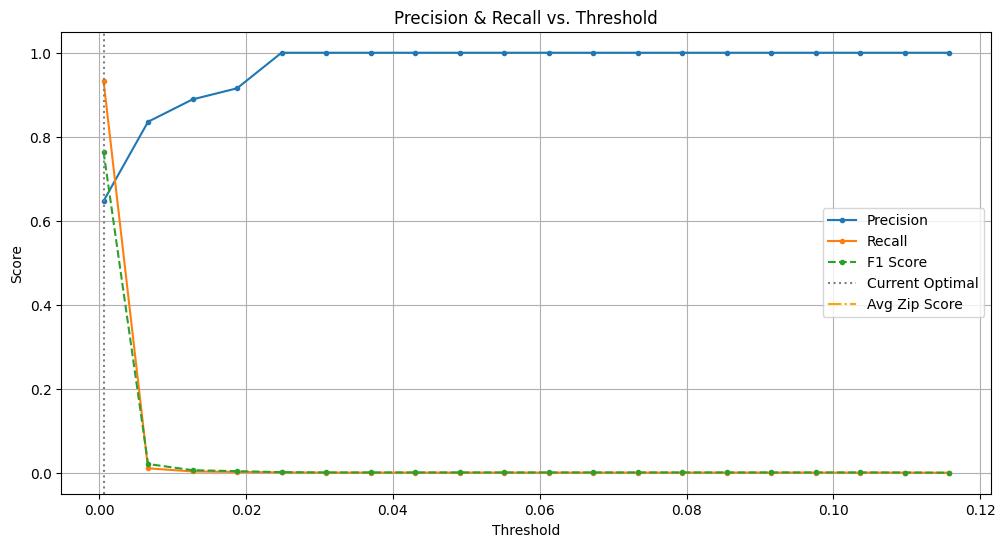

In [ ]:
start = optimal_threshold_new
stop = anomaly_scores_new.max()
thresholds_to_test = np.linspace(start, stop, 20)

results = []

for t in thresholds_to_test:
    y_pred_t = (anomaly_scores_new >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    results.append({'Threshold': t, 'Precision': prec, 'Recall': rec, 'F1': f1})

threshold_df = pd.DataFrame(results)

print("Effect of Increasing Threshold on Metrics:")
display(threshold_df.round(4))

plt.figure(figsize=(12, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], label='Precision', marker='.')
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], label='Recall', marker='.')
plt.plot(threshold_df['Threshold'], threshold_df['F1'], label='F1 Score', marker='.', linestyle='--')
plt.axvline(x=optimal_threshold_new, color='grey', linestyle=':', label='Current Optimal')

avg_zip_score = results_df[results_df['operation'] == 'Zip']['anomaly_score'].mean()
plt.axvline(x=avg_zip_score, color='orange', linestyle='-.', label='Avg Zip Score')

plt.title('Precision & Recall vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

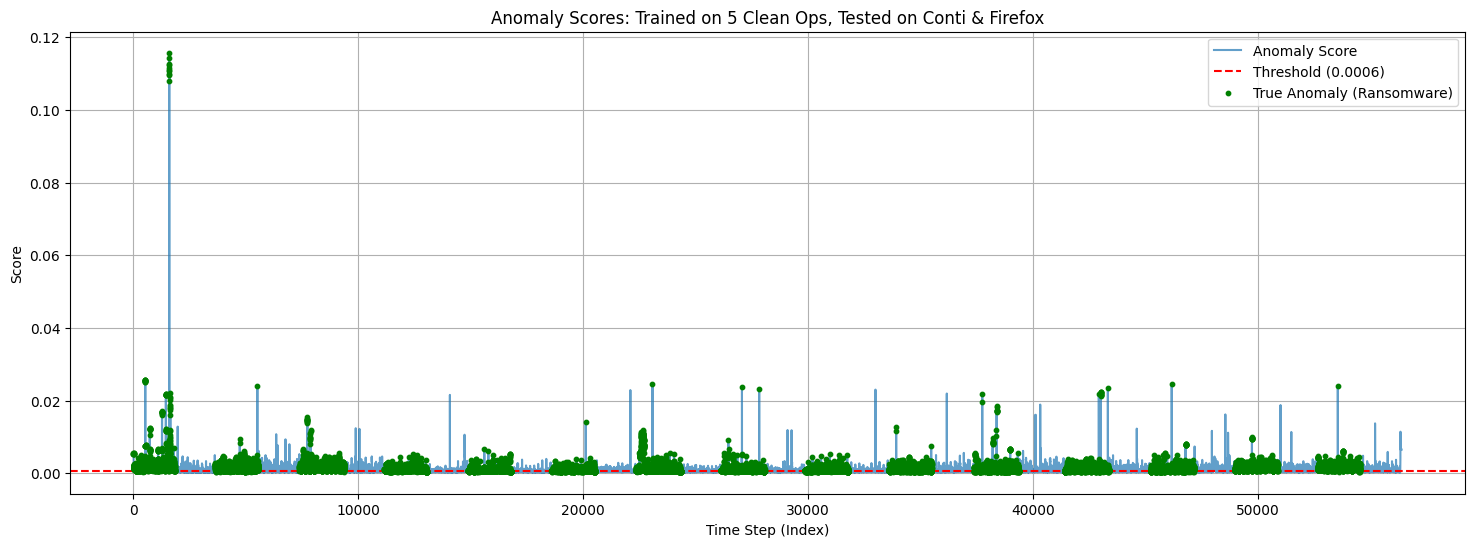

In [ ]:
time_index_new = np.arange(len(anomaly_scores_new))

plt.figure(figsize=(18, 6))
plt.plot(time_index_new, anomaly_scores_new, label='Anomaly Score', alpha=0.7)
plt.axhline(y=optimal_threshold_new, color='r', linestyle='--', label=f'Threshold ({optimal_threshold_new:.4f})')

true_anomalies = time_index_new[y_test == 1]
if len(true_anomalies) > 0:
    plt.scatter(true_anomalies, anomaly_scores_new[true_anomalies], color='g', label='True Anomaly (Ransomware)', s=10, zorder=5)

plt.title(f'Anomaly Scores: Trained on 5 Clean Ops, Tested on {selected_test_ransomware_operation} & {selected_test_non_ransomware_operation}')
plt.xlabel('Time Step (Index)')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()

Average Anomaly Score by Operation:
operation
Conti      0.001419
Firefox    0.000847
Name: anomaly_score, dtype: float32

Detection Rate (Percentage classified as Anomaly) by Operation:
operation
Conti      0.933377
Firefox    0.537887
Name: predicted_label, dtype: float64


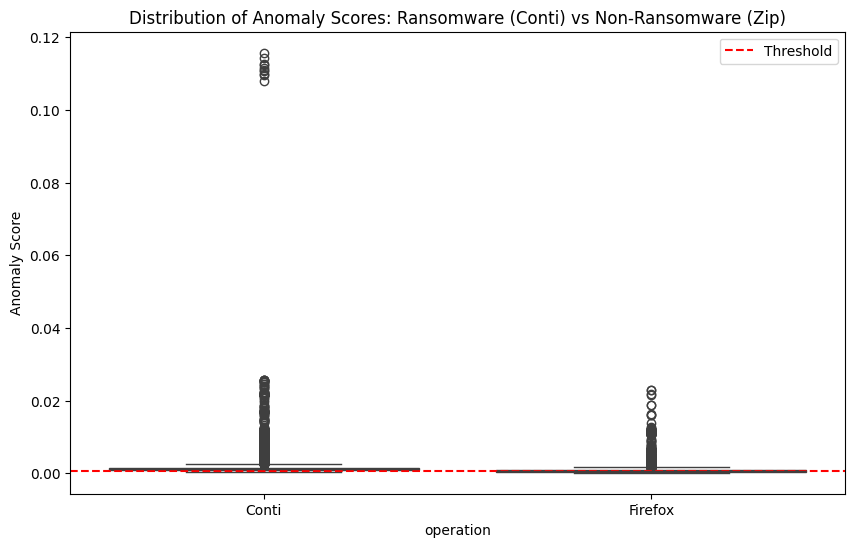

In [ ]:
results_df = df_test_filtered.copy()
results_df['anomaly_score'] = anomaly_scores_new
results_df['predicted_label'] = y_pred_new

print("Average Anomaly Score by Operation:")
print(results_df.groupby('operation')['anomaly_score'].mean())

print("\nDetection Rate (Percentage classified as Anomaly) by Operation:")
print(results_df.groupby('operation')['predicted_label'].mean())

plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x='operation', y='anomaly_score')
plt.axhline(y=optimal_threshold_new, color='r', linestyle='--', label='Threshold')
plt.title('Distribution of Anomaly Scores: Ransomware (Conti) vs Non-Ransomware (Zip)')
plt.ylabel('Anomaly Score')
plt.legend()
plt.show()

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

all_results = []

epochs = 10
batch_size = 128
lr = 1e-4
window_size = 15

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for ransomware_op in ransomware_operations:
    for non_ransomware_op in non_ransomware_operations:
        print(f"\nProcessing: Ransomware='{ransomware_op}', Non-Ransomware='{non_ransomware_op}'")

        df_train_current = df[df['operation'] == non_ransomware_op].copy()

        X_train_raw_current = df_train_current[input_features].values
        y_train_current = df_train_current['is_ransomware'].astype(int).values

        df_test_current = df[df['operation'].isin([non_ransomware_op, ransomware_op])].copy()

        X_test_raw_current = df_test_current[input_features].values
        y_test_current = df_test_current['is_ransomware'].astype(int).values

        current_result = {
            'ransomware_operation': ransomware_op,
            'non_ransomware_operation': non_ransomware_op,
            'roc_auc': np.nan, 'precision': np.nan, 'recall': np.nan, 'f1_score': np.nan, 'auc_pr': np.nan
        }

        if X_train_raw_current.shape[0] == 0 or X_test_raw_current.shape[0] == 0:
            print("  Skipping: Training or Test data is empty.")
            all_results.append(current_result)
            continue

        stds_current = np.std(X_train_raw_current, axis=0)
        zero_std_cols_mask_current = (stds_current == 0)

        X_train_filtered_current = X_train_raw_current[:, ~zero_std_cols_mask_current]
        X_test_filtered_current = X_test_raw_current[:, ~zero_std_cols_mask_current]

        feature_dim_current = X_train_filtered_current.shape[1]

        if feature_dim_current == 0:
            print("  Skipping: No features remaining after removing zero-std columns.")
            all_results.append(current_result)
            continue

        X_train_filtered_current = np.nan_to_num(X_train_filtered_current, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_filtered_current = np.nan_to_num(X_test_filtered_current, nan=0.0, posinf=0.0, neginf=0.0)

        scaler_current = MinMaxScaler()
        X_train_scaled_current = scaler_current.fit_transform(X_train_filtered_current)
        X_test_scaled_current = scaler_current.transform(X_test_filtered_current)

        if np.sum(np.isnan(X_train_scaled_current)) > 0 or np.sum(np.isinf(X_train_scaled_current)) > 0 or \
           np.sum(np.isnan(X_test_scaled_current)) > 0 or np.sum(np.isinf(X_test_scaled_current)) > 0:
            print("  Skipping: NaN/Inf values found after scaling.")
            all_results.append(current_result)
            continue

        model_tsbad_current = TranAD(
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            feats=feature_dim_current,
            win_size=window_size
        )

        try:
            model_tsbad_current.fit(X_train_scaled_current)
        except Exception as e:
            print(f"  Skipping: Error during model training: {e}")
            all_results.append(current_result)
            continue

        anomaly_scores_current = model_tsbad_current.decision_function(X_test_scaled_current)

        if len(np.unique(y_test_current)) < 2:
            print("  Skipping metrics: y_test_current contains only one class.")
            all_results.append(current_result)
            continue

        roc_auc_current = roc_auc_score(y_test_current, anomaly_scores_current)

        precision, recall, thresholds = precision_recall_curve(y_test_current, anomaly_scores_current)
        f1_scores = 2 * (precision * recall) / (precision + recall)
        f1_scores[np.isnan(f1_scores)] = 0

        if len(f1_scores) == 0:
            print("  Skipping metrics: Precision-Recall curve is empty.")
            all_results.append(current_result)
            continue

        optimal_threshold_idx = np.argmax(f1_scores)
        optimal_threshold_current = thresholds[optimal_threshold_idx]

        y_pred_current = (anomaly_scores_current >= optimal_threshold_current).astype(int)

        precision_current = precision_score(y_test_current, y_pred_current, zero_division=0)
        recall_current = recall_score(y_test_current, y_pred_current, zero_division=0)
        f1_score_current = f1_score(y_test_current, y_pred_current, zero_division=0)

        auc_pr_current = auc(recall, precision)

        current_result.update({
            'roc_auc': roc_auc_current,
            'precision': precision_current,
            'recall': recall_current,
            'f1_score': f1_score_current,
            'auc_pr': auc_pr_current
        })
        all_results.append(current_result)

results_df_all_pairs = pd.DataFrame(all_results)
print("\n--- All Iterations Complete ---")
print(f"Results DataFrame shape: {results_df_all_pairs.shape}")
print("First 5 rows of results:")
display(results_df_all_pairs.head())

Using device: cuda

Processing: Ransomware='Conti', Non-Ransomware='AESCrypt'
----- Using GPU 0 -----


100%|██████████| 447/447 [00:02<00:00, 188.65it/s]



Processing: Ransomware='Conti', Non-Ransomware='AESCrypt_Conti'
----- Using GPU 0 -----


100%|██████████| 241/241 [00:01<00:00, 185.20it/s]



Processing: Ransomware='Conti', Non-Ransomware='AESCrypt_REvil'
----- Using GPU 0 -----


...

100%|██████████| 239/239 [00:01<00:00, 186.07it/s]



Processing: Ransomware='LockBit', Non-Ransomware='AESCrypt'
----- Using GPU 0 -----


Validation Epoch [4/10]:  53%|█████▎    | 24/45 [00:00<00:00, 72.89it/s, avg_loss_val=0.00377, loss=0.00727] 
ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-3755426785.py", line 93, in <cell line: 0>
    model_tsbad_current.fit(X_train_scaled_current)
  File "/usr/local/lib/python3.12/dist-packages/TSB_AD/models/TranAD.py", line 226, in fit
    z = self.model(x, elem)
        ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1775, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1786, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/TSB_AD/models/TranAD.py", line 124, in forward
    x2 = self.fcn(self.transformer_decoder2(*self.encode(sr

TypeError: object of type 'NoneType' has no len()

In [ ]:
ransomware_operations = ['Conti', 'Darkside', 'LockBit', 'REvil', 'Ryuk', 'WannaCry']
restricted_non_ransomware_operations = ['AESCrypt', 'Zip', 'Idle', 'Office', 'SDelete', 'Firefox']
all_results = []

print(f"Ransomware Operations: {ransomware_operations}")
print(f"Restricted Non-Ransomware Operations: {restricted_non_ransomware_operations}")
print(f"Initialized empty list for all results: {len(all_results)}")

Ransomware Operations: ['Conti', 'Darkside', 'LockBit', 'REvil', 'Ryuk', 'WannaCry']
Restricted Non-Ransomware Operations: ['AESCrypt', 'Zip', 'Idle', 'Office', 'SDelete', 'Firefox']
Initialized empty list for all results: 0


Using device: cuda

Processing: Ransomware='Conti' (Test), Non-Ransomware (Test)='AESCrypt'
----- Using GPU 0 -----


Validation Epoch [7/10]: 100%|██████████| 214/214 [00:01<00:00, 134.11it/s, avg_loss_val=0.000835, loss=0.00196]


EarlyStopping counter: 1 out of 3


Validation Epoch [9/10]: 100%|██████████| 214/214 [00:01<00:00, 132.89it/s, avg_loss_val=0.000681, loss=0.00149]


EarlyStopping counter: 1 out of 3


...

  F1-score: 0.6683, ROC_AUC: 0.0242

Processing: Ransomware='WannaCry' (Test), Non-Ransomware (Test)='Firefox'
----- Using GPU 0 -----


Validation Epoch [10/10]: 100%|██████████| 215/215 [00:01<00:00, 129.52it/s, avg_loss_val=0.000688, loss=0.000999]


EarlyStopping counter: 1 out of 3


100%|██████████| 432/432 [00:02<00:00, 193.71it/s]
/tmp/ipython-input-3598511525.py:140: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


  F1-score: 0.7421, ROC_AUC: 0.6660

--- All Iterations Complete ---


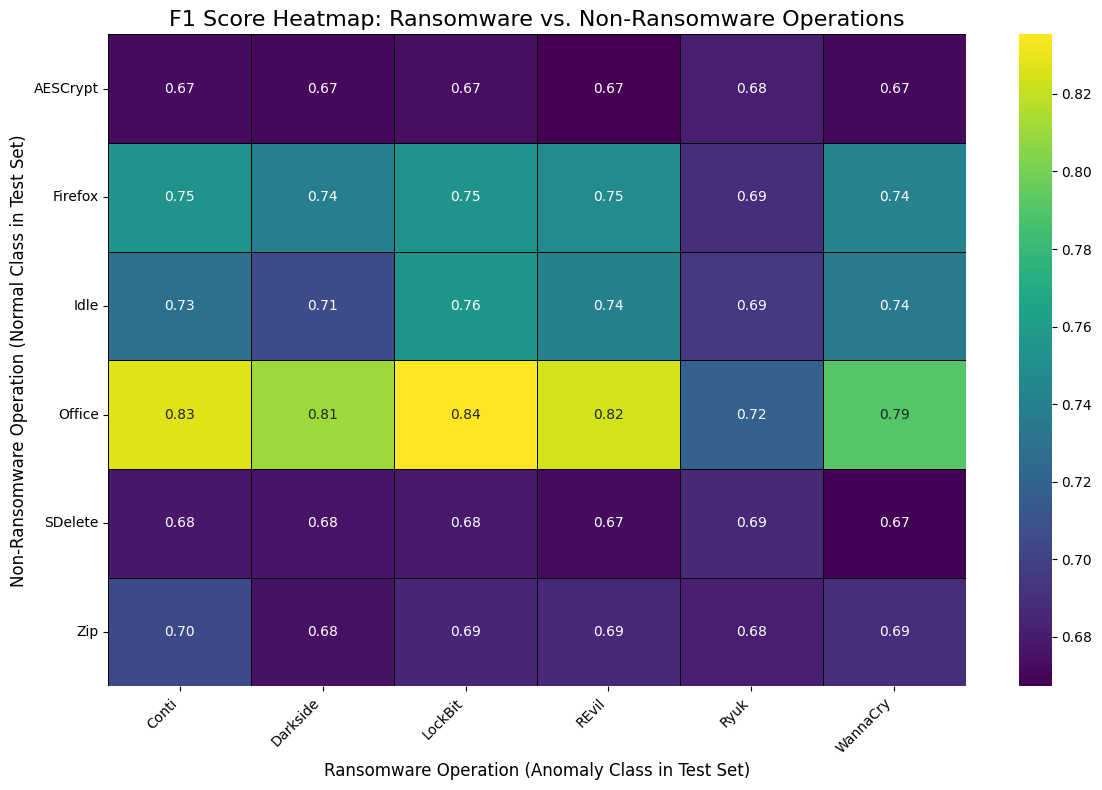


--- Comprehensive Summary of Model Performance ---
The heatmap above visualizes the F1-scores for anomaly detection across different combinations of ransomware and non-ransomware operations.
Each cell represents the F1-score when the model is trained on a set of non-ransomware operations (excluding the one in the test set) and then tested against a specific ransomware operation and one specific non-ransomware operation.

Key observations from the F1-score heatmap:

Average F1-score for detecting each ransomware operation (across different non-ransomware test cases):
ransomware_operation
LockBit     0.73
Conti       0.73
REvil       0.72
WannaCry    0.72
Darkside    0.71
Ryuk        0.69
Name: F1_score, dtype: float64

Average F1-score when a specific non-ransomware operation is part of the test set (across different ransomware types):
non_ransomware_operation
Office      0.80
Firefox     0.74
Idle        0.73
Zip         0.69
SDelete     0.68
AESCrypt    0.67
Name: F1_score, dtype: fl

,ransomware_operation,non_ransomware_operation,F1_score,Precision,Recall,ROC_AUC,AUCPR
0,Conti,AESCrypt,0.672075,0.506127,0.999931,0.346759,0.413869
1,Conti,Zip,0.704059,0.576661,0.903709,0.697512,0.691842
2,Conti,Idle,0.728745,0.587597,0.959142,0.633101,0.575651
3,Conti,Office,0.827053,0.747220,0.925986,0.849050,0.800220
4,Conti,SDelete,0.677350,0.512116,1.000000,0.034757,0.320325
5,Conti,Firefox,0.753415,0.632092,0.932375,0.701319,0.615178
6,Darkside,AESCrypt,0.670834,0.504747,0.999826,0.172988,0.340273
7,Darkside,Zip,0.675065,0.511877,0.990997,0.444582,0.488270
8,Darkside,Idle,0.705698,0.551179,0.980604,0.506038,0.485018
9,Darkside,Office,0.810744,0.717896,0.931176,0.807740,0.738196


In [18]:
warnings.filterwarnings("ignore", category=UserWarning)

ransomware_operations = ['Conti', 'Darkside', 'LockBit', 'REvil', 'Ryuk', 'WannaCry']
restricted_non_ransomware_operations = ['AESCrypt', 'Zip', 'Idle', 'Office', 'SDelete', 'Firefox']

all_results = []

epochs = 10
batch_size = 128
lr = 1e-4
window_size = 15

device = 'cuda' if torch.cuda.is_available() else 'cpu'

for ransomware_op in ransomware_operations:
    for non_ransomware_op_test in restricted_non_ransomware_operations:
        print(f"\nProcessing: Ransomware='{ransomware_op}' (Test), Non-Ransomware (Test)='{non_ransomware_op_test}'")

        train_ops_for_this_iteration = [op for op in restricted_non_ransomware_operations if op != non_ransomware_op_test]

        if not train_ops_for_this_iteration:
            print(f"  Skipping pair: No other non-ransomware operations available for training when testing with '{non_ransomware_op_test}'.")
            current_result = {
                'ransomware_operation': ransomware_op,
                'non_ransomware_operation_test': non_ransomware_op_test,
                'F1_score': np.nan, 'Precision': np.nan, 'Recall': np.nan,
                'ROC_AUC': np.nan, 'AUCPR': np.nan
            }
            all_results.append(current_result)
            continue

        df_train_current = df[df['operation'].isin(train_ops_for_this_iteration)].copy()
        X_train_raw_current = df_train_current[input_features].values
        y_train_current = df_train_current['is_ransomware'].astype(int).values

        test_ops_for_this_iteration = [non_ransomware_op_test, ransomware_op]
        df_test_current = df[df['operation'].isin(test_ops_for_this_iteration)].copy()
        X_test_raw_current = df_test_current[input_features].values
        y_test_current = df_test_current['is_ransomware'].astype(int).values

        current_result = {
            'ransomware_operation': ransomware_op,
            'non_ransomware_operation_test': non_ransomware_op_test,
            'F1_score': np.nan, 'Precision': np.nan, 'Recall': np.nan, 'ROC_AUC': np.nan, 'AUCPR': np.nan
        }

        if X_train_raw_current.shape[0] == 0:
            print(f"  Skipping: Training data is empty for non-ransomware ops: {train_ops_for_this_iteration}.")
            all_results.append(current_result)
            continue
        if X_test_raw_current.shape[0] == 0:
            print(f"  Skipping: Test data is empty for ops: {test_ops_for_this_iteration}.")
            all_results.append(current_result)
            continue

        stds_current = np.std(X_train_raw_current, axis=0)
        zero_std_cols_mask_current = (stds_current == 0)

        X_train_filtered_current = X_train_raw_current[:, ~zero_std_cols_mask_current]
        X_test_filtered_current = X_test_raw_current[:, ~zero_std_cols_mask_current]

        feature_dim_current = X_train_filtered_current.shape[1]

        if feature_dim_current == 0:
            print("  Skipping: No features remaining after removing zero-std columns.")
            all_results.append(current_result)
            continue

        X_train_filtered_current = np.nan_to_num(X_train_filtered_current, nan=0.0, posinf=0.0, neginf=0.0)
        X_test_filtered_current = np.nan_to_num(X_test_filtered_current, nan=0.0, posinf=0.0, neginf=0.0)

        scaler_current = MinMaxScaler()
        X_train_scaled_current = scaler_current.fit_transform(X_train_filtered_current)
        X_test_scaled_current = scaler_current.transform(X_test_filtered_current)

        if np.sum(np.isnan(X_train_scaled_current)) > 0 or np.sum(np.isinf(X_train_scaled_current)) > 0 or \
           np.sum(np.isnan(X_test_scaled_current)) > 0 or np.sum(np.isinf(X_test_scaled_current)) > 0:
            print("  Skipping: NaN/Inf values found after scaling.")
            all_results.append(current_result)
            continue

        model_tsbad_current = TranAD(
            epochs=epochs,
            batch_size=batch_size,
            lr=lr,
            feats=feature_dim_current,
            win_size=window_size
        )

        try:
            model_tsbad_current.fit(X_train_scaled_current)
        except Exception as e:
            print(f"  Skipping: Error during model training: {e}")
            all_results.append(current_result)
            continue

        anomaly_scores_current = model_tsbad_current.decision_function(X_test_scaled_current)

        if len(np.unique(y_test_current)) < 2:
            print("  Skipping metrics: y_test_current contains only one class.")
            all_results.append(current_result)
            continue

        roc_auc_current = roc_auc_score(y_test_current, anomaly_scores_current)

        precision, recall, thresholds = precision_recall_curve(y_test_current, anomaly_scores_current)
        f1_scores = 2 * (precision * recall) / (precision + recall)
        f1_scores[np.isnan(f1_scores)] = 0

        if len(f1_scores) == 0:
            print("  Skipping metrics: Precision-Recall curve is empty.")
            all_results.append(current_result)
            continue

        optimal_threshold_idx = np.argmax(f1_scores)
        optimal_threshold_current = thresholds[optimal_threshold_idx]

        y_pred_current = (anomaly_scores_current >= optimal_threshold_current).astype(int)

        precision_current = precision_score(y_test_current, y_pred_current, zero_division=0)
        recall_current = recall_score(y_test_current, y_pred_current, zero_division=0)
        f1_score_current = f1_score(y_test_current, y_pred_current, zero_division=0)

        auc_pr_current = auc(recall, precision)

        current_result.update({
            'ROC_AUC': roc_auc_current,
            'Precision': precision_current,
            'Recall': recall_current,
            'F1_score': f1_score_current,
            'AUCPR': auc_pr_current
        })
        all_results.append(current_result)
        print(f"  F1-score: {f1_score_current:.4f}, ROC_AUC: {roc_auc_current:.4f}")

print("\n--- All Iterations Complete ---")

results_df_all_pairs = pd.DataFrame(all_results)
results_df_all_pairs.rename(columns={'non_ransomware_operation_test': 'non_ransomware_operation'}, inplace=True)

heatmap_data = results_df_all_pairs.pivot(index='non_ransomware_operation', columns='ransomware_operation', values='F1_score')

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis", linewidths=.5, linecolor='black')
plt.title('F1 Score Heatmap: Ransomware vs. Non-Ransomware Operations', fontsize=16)
plt.xlabel('Ransomware Operation (Anomaly Class in Test Set)', fontsize=12)
plt.ylabel('Non-Ransomware Operation (Normal Class in Test Set)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


avg_f1_by_ransomware = results_df_all_pairs.groupby('ransomware_operation')['F1_score'].mean().sort_values(ascending=False)
print("\nAverage F1-score for detecting each ransomware operation (across different non-ransomware test cases):")
print(avg_f1_by_ransomware.round(2))

avg_f1_by_non_ransomware_test = results_df_all_pairs.groupby('non_ransomware_operation')['F1_score'].mean().sort_values(ascending=False)
print("\nAverage F1-score when a specific non-ransomware operation is part of the test set (across different ransomware types):")
print(avg_f1_by_non_ransomware_test.round(2))

print("\nDetailed F1 Score and other metrics for all combinations:")
display(results_df_all_pairs)

In [19]:
overall_avg_f1_score = results_df_all_pairs['F1_score'].mean()
overall_avg_precision = results_df_all_pairs['Precision'].mean()
overall_avg_recall = results_df_all_pairs['Recall'].mean()

print(f"Overall Average F1-score: {overall_avg_f1_score:.4f}")
print(f"Overall Average Precision: {overall_avg_precision:.4f}")
print(f"Overall Average Recall: {overall_avg_recall:.4f}")

Overall Average F1-score: 0.7169
Overall Average Precision: 0.5787
Overall Average Recall: 0.9581
